## Viewing ARIAS Data

In [1]:
import sys, os, glob
sys.path.append('/users/egottfri/code/octa-segmentation/src')

import numpy as np
import h5py
import cv2
import matplotlib.pyplot as plt
import torch

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', device)

ARIAS_DIR = '/oscar/data/jlee123/procdata/adp/22-retina-arias-y1/'

torch 2.7.1+cu118 | device: cuda


In [6]:
import numpy as np, h5py, matplotlib.pyplot as plt
path = h5_files[0]
with h5py.File(path, 'r') as f:
    print('lyrComb (2,3):\n', f['p1/opt/lyrComb'][()])
    print('lyrZ  (14 layer depths):', np.round(f['r1/lyrZ'][()].ravel(), 1))
    lyr = f['r1/lyr']
    print('lyr', lyr.shape, lyr.dtype,
          '| codes present (subsampled):', np.unique(lyr[::8, ::8, ::8]))
    print('SEG surfaces:', f['p1/hdrBscanAng/SEG'].shape[0])

lyrComb (2,3):
 [[ 2.  8. inf]
 [ 6.  8. inf]]
lyrZ  (14 layer depths): [167.6 193.3 195.3 203.1 206.6 211.7 218.7 225.2 229.8 242.1 247.5 253.1
 257.5 279.4]
lyr (512, 512, 496) uint8 | codes present (subsampled): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
SEG surfaces: 19


In [7]:
def _stretch(p):
    p[~np.isfinite(p)] = 0
    lo, hi = np.percentile(p, 1), np.percentile(p, 99)
    return (np.clip((p - lo) / max(hi - lo, 1e-6), 0, 1) * 255).astype(np.uint8)

def slab_from_lyr(path, codes, vol='octa'):
    """MIP `vol` over voxels whose r1/lyr code is in `codes`. Frame-agnostic:
       lyr is co-registered with the volume it labels, so no z-convention guessing."""
    with h5py.File(path, 'r') as f:
        v   = f[vol][()].astype(np.float32)   # (y, x, z)
        lyr = f['r1/lyr'][()]                 # (y, x, z) uint8, codes 0..14
    mask = np.isin(lyr, codes)
    proj = np.where(mask, v, -np.inf).max(axis=2)
    coverage = mask.any(axis=2).mean()        # frac of A-lines with any labeled voxel
    return _stretch(proj), coverage

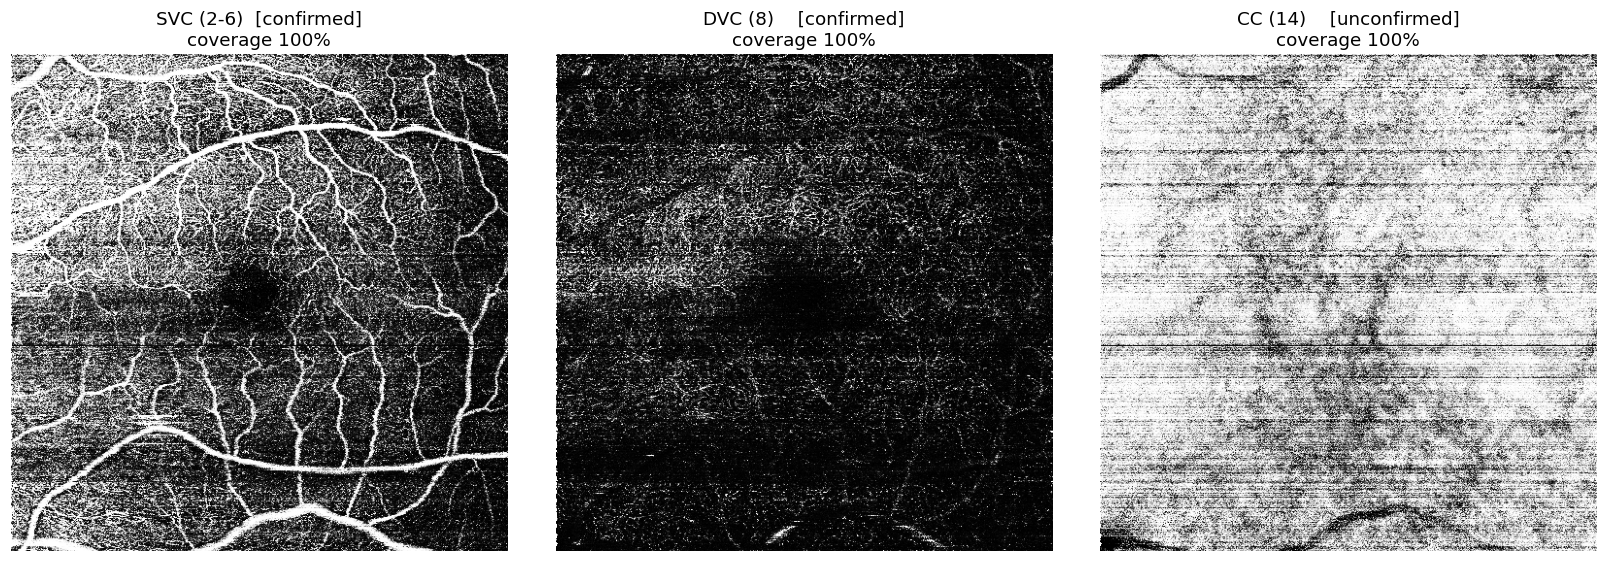

In [8]:
candidates = [
    ('SVC (2-6)  [confirmed]', [2, 3, 4, 5, 6]),
    ('DVC (8)    [confirmed]', [8]),
    ('CC (14)    [unconfirmed]', [14]),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for a, (name, codes) in zip(axes, candidates):
    enf, cov = slab_from_lyr(h5_files[0], codes)
    a.imshow(enf, cmap='gray'); a.set_title(f'{name}\ncoverage {cov:.0%}'); a.axis('off')
plt.tight_layout(); plt.show()